In [41]:
!which python

/home/midori/Desktop/Nural_Network/nural_venv/bin/python


In [87]:
# imports
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

In [43]:
(X_train,Y_train),(X_test,Y_test) = keras.datasets.mnist.load_data()

In [44]:
X_train = X_train/255
X_test = X_test/255

In [45]:
len(X_train)

60000

In [46]:
len(X_test)

10000

In [47]:
X_train[0].shape

(28, 28)

In [48]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

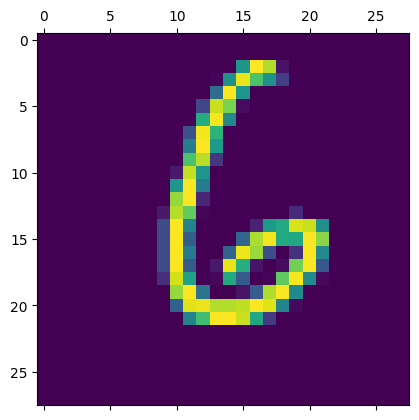

In [49]:
plt.matshow(X_train[32])

In [50]:
X_train.shape

(60000, 28, 28)

In [51]:
X_train_flattened = X_train.reshape(len(X_train),28*28)
X_test_flattened = X_test.reshape(len(X_test),28*28)
X_train_flattened.shape

(60000, 784)

In [52]:
model = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
model.fit(X_train_flattened,Y_train,epochs=9)

Epoch 1/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.9269 - loss: 0.2620
Epoch 2/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 775us/step - accuracy: 0.9292 - loss: 0.2583
Epoch 3/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 807us/step - accuracy: 0.9295 - loss: 0.2553
Epoch 4/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step - accuracy: 0.9297 - loss: 0.2533
Epoch 5/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.9310 - loss: 0.2509
Epoch 6/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 797us/step - accuracy: 0.9310 - loss: 0.2488
Epoch 7/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.9308 - loss: 0.2478
Epoch 8/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 797us/step - accuracy: 0.9316 - loss: 0.2462
Epoch 9/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.9316 - loss: 0.2455


In [56]:
model.evaluate(X_test_flattened,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - accuracy: 0.9255 - loss: 0.2678


[0.2677628695964813, 0.9254999756813049]

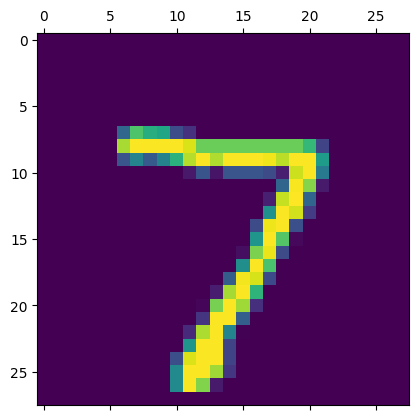

In [76]:
plt.matshow(X_test[0])

In [73]:
Y_predicted = model.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step


In [77]:
Y_predicted[0]

array([1.6933718e-07, 6.6077509e-13, 8.2054845e-07, 6.7674243e-03,
       1.6745533e-07, 1.5189308e-05, 4.4013244e-13, 9.9297088e-01,
       7.8895237e-06, 2.3758580e-04], dtype=float32)

In [80]:
Y_predicted_labels = [np.argmax(i) for i in Y_predicted]
Y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [82]:
Y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [79]:
np.argmax(Y_predicted[0])

np.int64(7)

In [84]:
cm = tf.math.confusion_matrix(labels=Y_test,predictions=Y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 960,    0,    1,    2,    0,    6,    7,    3,    1,    0],
       [   0, 1119,    3,    2,    0,    1,    3,    2,    5,    0],
       [   4,   11,  935,   18,    7,    4,   11,    9,   28,    5],
       [   3,    0,   16,  936,    1,   21,    2,    9,   15,    7],
       [   1,    3,    5,    2,  908,    0,   12,    4,    8,   39],
       [   8,    3,    2,   47,    8,  767,   14,    9,   27,    7],
       [  11,    3,    9,    1,    7,   15,  909,    1,    2,    0],
       [   1,    6,   24,    8,    6,    1,    0,  943,    3,   36],
       [   6,   14,    6,   34,    9,   26,    7,   11,  850,   11],
       [   9,    8,    1,   14,   23,    5,    0,   16,    5,  928]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

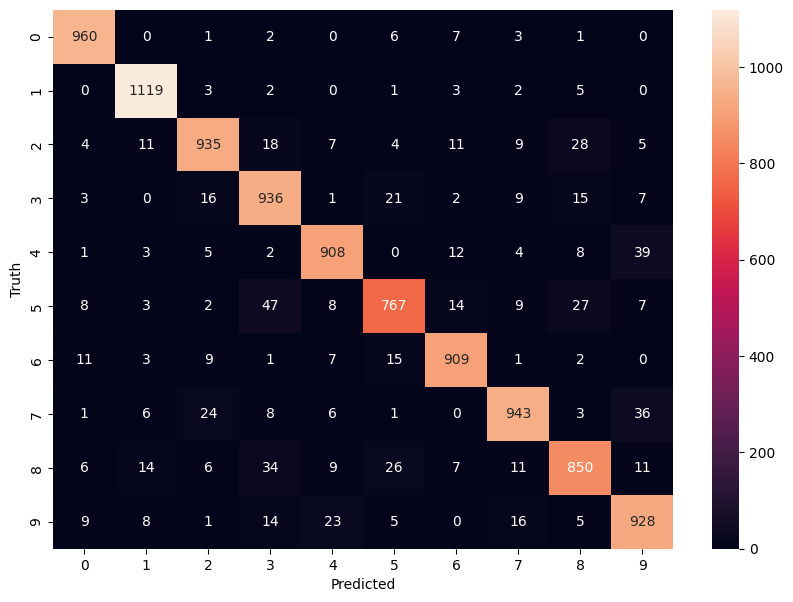

In [88]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [97]:
model2 = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(120, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [98]:
model2.fit(X_train_flattened,Y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9243 - loss: 0.2629
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9654 - loss: 0.1176
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9753 - loss: 0.0811
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9820 - loss: 0.0609
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9844 - loss: 0.0488


In [99]:
model2.evaluate(X_test_flattened,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - accuracy: 0.9783 - loss: 0.0742


[0.07419027388095856, 0.9782999753952026]

In [101]:
Y_predicted2 = model2.predict(X_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step


In [102]:
Y_predicted_labels2 = [np.argmax(i) for i in Y_predicted2]
Y_predicted_labels2[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [103]:
cm2 = tf.math.confusion_matrix(labels=Y_test,predictions=Y_predicted_labels2)

Text(95.72222222222221, 0.5, 'Truth')

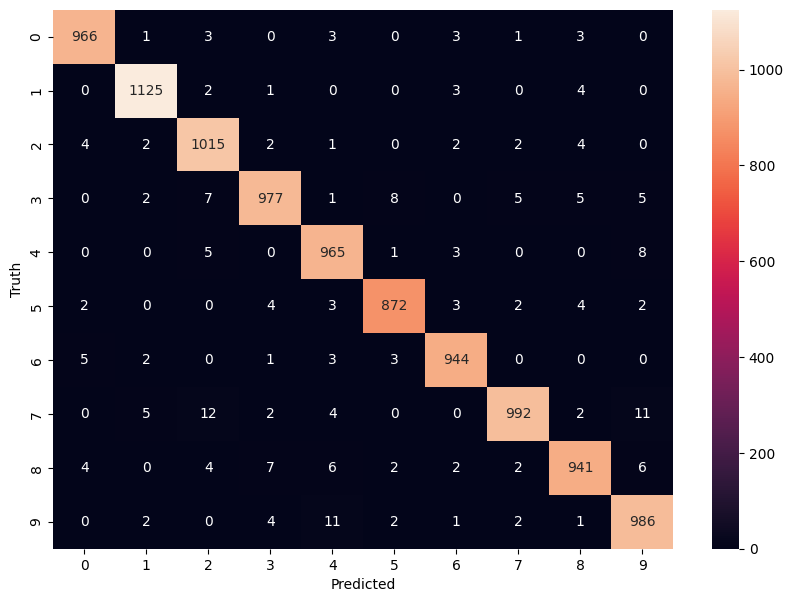

In [105]:
plt.figure(figsize=(10,7))
sn.heatmap(cm2,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')